# Analysis of mutations

In [1]:
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import combinations

# from scipy.stats import linregress
# from matplotlib_venn import venn2
# from tqdm import tqdm
# tqdm.pandas()

In [2]:
all_mutrates = pd.read_table(f"all_mutdensities.tsv")

In [3]:
full_cohort_metadata = pd.read_table("20250516_metadata_bladder.with_depths.tsv")
full_cohort_metadata.head()

,SAMPLE_ID,SUBJECT_ID,AGE,SEX,BMI,SMOKING_STATUS,HISTORY_OF_SMOKING,CURRENT_SMOKER,ALCOHOL_GROUP,HISTORY_OF_DRINKING,...,NOTCH2_depth,FOXQ1_depth,CDKN1A_depth,KMT2C_depth,TP53_depth,RB1_depth,FGFR3_depth,PIK3CA_depth,TERTpromoter_depth,total_depth
0,P19_0047_BDO_01,P19_0047,46,M,29.9,former,yes,no,former,yes,...,6866.809023,4604.716364,12537.872222,8061.174839,10219.111423,7411.275842,10154.727518,8533.763889,1217.225989,7219.964358
1,P19_0009_BTR_01,P19_0009,56,F,32.8,current,yes,yes,heavy,yes,...,3582.336286,20081.660000,22902.629630,3906.232083,9616.333567,3643.054758,19295.271583,2809.628472,2877.779661,8327.585211
2,P19_0008_BDO_01,P19_0008,72,M,28.3,former,yes,no,occasional,yes,...,5380.276086,2035.886364,4938.668519,6636.928112,5494.578136,4971.831625,2959.359712,5894.118056,1441.333333,4372.224383
3,P19_0001_BTR_01,P19_0001,24,M,30.1,never,no,no,no,no,...,6541.577498,2180.124545,7210.483333,7638.135789,6367.466713,5440.150512,3755.018885,6841.708333,490.768362,5105.737962
4,P19_0041_BDO_01,P19_0041,59,F,52.7,never,no,no,NaN,NaN,...,4657.111403,2385.021818,5453.885185,5192.524296,4991.056762,5017.462665,4003.279676,5407.927083,1000.299435,4480.454219


In [4]:
subset_mutrates = all_mutrates[(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]
subset_mutrates_annotated = subset_mutrates.merge(full_cohort_metadata, on='SAMPLE_ID')
subset_mutrates_annotated.head()

,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSRATE_MB,...,NOTCH2_depth,FOXQ1_depth,CDKN1A_depth,KMT2C_depth,TP53_depth,RB1_depth,FGFR3_depth,PIK3CA_depth,TERTpromoter_depth,total_depth
0,P19_0007_BTR_01,ALL_GENES,all,SNV,553100541,241.0,275.0,0.435725,0.435725,0.497197,...,4472.958068,3004.605455,4551.298148,6139.920124,6555.826910,3965.061786,5519.119604,4985.871528,2621.920904,4573.389682
1,P19_0046_BTR_01,ALL_GENES,all,SNV,310723023,267.0,453.0,0.859286,0.859286,1.457890,...,2289.982701,10447.936364,6623.488889,3074.234080,1752.609671,3565.864422,5184.281475,2404.562500,299.774011,3142.133921
2,P19_0013_BTR_01,ALL_GENES,all,SNV,455742968,116.0,118.0,0.254529,0.254529,0.258918,...,3721.398699,1620.313636,4136.350000,4643.565565,3830.855641,4031.235139,2247.937050,4765.697917,353.288136,3516.711544
3,P19_0020_BTR_01,ALL_GENES,all,SNV,873942970,344.0,368.0,0.393618,0.393618,0.421080,...,7165.314974,3238.576364,6287.809259,8243.621034,7790.384022,6438.402050,5497.611511,8139.201389,1244.661017,6601.966740
4,P19_0009_BDO_01,ALL_GENES,all,SNV,498473418,469.0,1358.0,0.940873,0.940873,2.724318,...,3665.422225,1344.500909,3917.446296,4352.411360,5027.231955,3437.712445,3484.423561,3944.923611,512.870056,3675.478613


In [5]:
subset_mutrates_annotated.columns

Index(['SAMPLE_ID', 'GENE', 'REGIONS', 'MUTTYPES', 'DEPTH', 'N_MUTS',
       'N_MUTATED', 'MUTDENSITY_MB', 'MUTDENSITY_MB_ADJUSTED',
       'MUTREADSRATE_MB', 'MUTREADSRATE_MB_ADJUSTED', 'SUBJECT_ID', 'AGE',
       'SEX', 'BMI', 'SMOKING_STATUS', 'HISTORY_OF_SMOKING', 'CURRENT_SMOKER',
       'ALCOHOL_GROUP', 'HISTORY_OF_DRINKING', 'CURRENT_DRINKER',
       'CANCER_HISTORY', 'CANCER_TYPE_SIMPLE', 'CHEMOTHERAPY_HISTORY_SIMPLE',
       'TYPE_CHEMOTHERAPY_MANUAL', 'BLADDER_FINDINGS',
       'HISTORY_URINARY_INFECTIONS', 'CAUSE_DEATH', 'ANCESTRY_ETHNICITY',
       'CURRENT_RESIDENCY_AREA', 'BLADDER_LOCATION', 'is_dome', 'is_male',
       'history_smoking', 'current_smoker', 'smoking_status', 'had_cancer',
       'had_prior_chemotherapy', 'is_above_reproductive_age',
       'history_drinking', 'current_drinker', 'history_urinary_infections',
       'is_white_ancestry', 'urban_residency', 'age_decades', 'bmi_scaled',
       'BMI_group', 'AGE_group', 'Sequencer', 'DIN', 'postmortem_days',
   

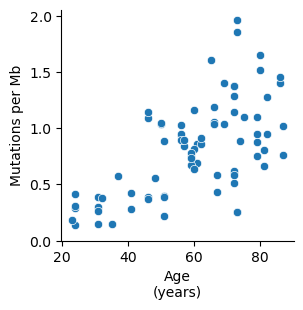

In [6]:
plt.figure(figsize = (3,3))
sns.scatterplot(data = subset_mutrates_annotated,
                x = 'AGE',
                y = "MUTDENSITY_MB",
                #hue = 'binary_smoking_status_unif',
                #palette=group_colors_palette
                )
plt.ylabel("Mutations per Mb")
plt.xlabel("Age\n(years)")
bottom, top = plt.ylim()
plt.ylim(0, top)
sns.despine()
plt.savefig('../../figures/figure5/mutdensity_age.png', bbox_inches = 'tight', dpi = 300)
plt.show()

### Relationship with depth

In [ ]:
subset_mutrates_all = all_mutrates[(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]

geness = [ 'ARID1A', 'CDKN1A', 'CREBBP',
          'EP300', 'FGFR3', 'FOXQ1', 'KDM6A',
          'KMT2C', 'KMT2D', 'NOTCH2', 'PIK3CA',
          'RB1', 'RBM10', 'STAG2',
          'TERTpromoter',
          'TP53']

# geness = [ #'ARID1A', 'CDKN1A', 'CREBBP',
#         #   'EP300', 'FGFR3',
#           'FOXQ1',
#         #   'KDM6A',
#         #   'KMT2C', 'KMT2D',
#         'NOTCH2',
#           'PIK3CA',
#         #   'RB1',
#         'RBM10',
#         #'STAG2',
#           'TERTpromoter',
#           'TP53']

subset_mutrates_sel = all_mutrates[~(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               (all_mutrates["GENE"].isin(geness)) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]

subset_mutrates_nosel = all_mutrates[~(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               ~(all_mutrates["GENE"].isin(geness)) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]
# subset_mutrates_annotated = subset_mutrates.merge(full_cohort_metadata, on='SAMPLE_ID')
# subset_mutrates_annotated.head()

In [16]:
subset_mutrates["GENE"].unique()

array(['ALL_GENES'], dtype=object)

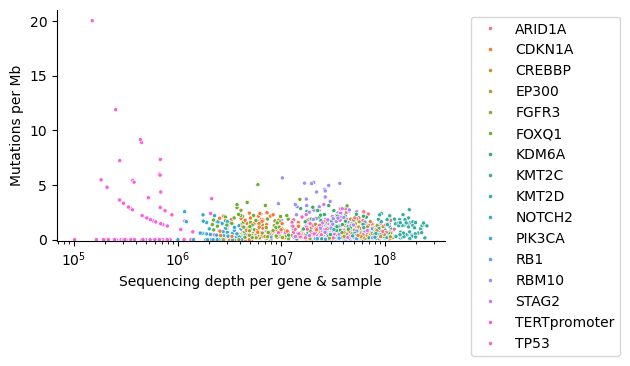

In [21]:
# sns.scatterplot(data = subset_mutrates_all,
#                 x = "DEPTH",
#                 y = "MUTDENSITY_MB",
#                )
plt.figure(figsize = (5,3))
sns.scatterplot(data = subset_mutrates_sel,
                x = "DEPTH",
                y = "MUTDENSITY_MB",
                hue = "GENE",
                marker = '.'
               )
# plt.yscale('log')
plt.xscale('log')
# plt.xlim(-100, 0.1e8)

bottom, top = plt.ylim()
plt.ylim(-0.1, top)
sns.despine()


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Sequencing depth per gene & sample")
plt.ylabel("Mutations per Mb")
plt.savefig('../../figures/extended/mutdensity_depth_selected_genes.png', bbox_inches = 'tight', dpi = 300)

plt.show()


# 'VAF_distorsion', 'VAF_Ns', 'VAF_Ns_AM'

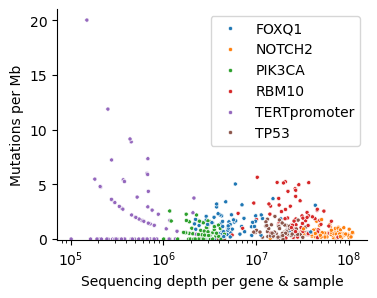

In [27]:
plt.figure(figsize = (4,3))
sns.scatterplot(data = subset_mutrates_sel,
                x = "DEPTH",
                y = "MUTDENSITY_MB",
                hue = "GENE",
                marker = '.'
               )
# plt.yscale('log')
plt.xscale('log')
# plt.xlim(-100, 0.1e8)

bottom, top = plt.ylim()
plt.ylim(-0.1, top)
sns.despine()


plt.legend(#bbox_to_anchor=(1.05, 1),
           loc='upper right')
plt.xlabel("Sequencing depth per gene & sample")
plt.ylabel("Mutations per Mb")
plt.savefig('../../figures/extended/mutdensity_depth_selected_genes_short.png', bbox_inches = 'tight', dpi = 300)

plt.show()


# 'VAF_distorsion', 'VAF_Ns', 'VAF_Ns_AM'

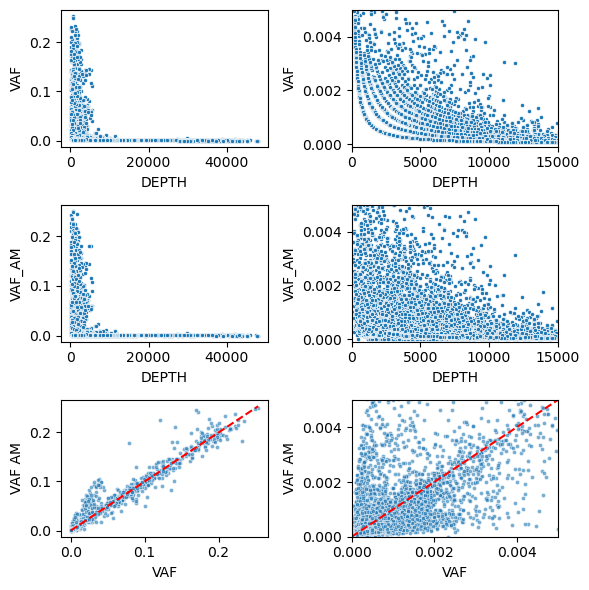

In [ ]:
df = somatic_maf_df

fig, ax = plt.subplots(3,2, figsize = (6, 6))
axes = ax.flatten()
i = 0
sns.scatterplot(data = df,
                x = "DEPTH",
                y = "VAF",
                #hue = "Protein_affecting",
                marker = '.',
                ax= axes[i]
               )

i += 1

sns.scatterplot(data = df,
                x = "DEPTH",
                y = "VAF",
                #hue = "Protein_affecting",
                marker = '.',
                ax= axes[i]
               )
axes[i].set_ylim(-0.0001,0.005)
axes[i].set_xlim(0,15000)

i += 1

sns.scatterplot(data = df,
                x = "DEPTH",
                y = "VAF_AM",
                #hue = "Protein_affecting",
                marker = '.',
                ax= axes[i]
               )

i += 1

sns.scatterplot(data = df,
                x = "DEPTH",
                y = "VAF_AM",
                #hue = "Protein_affecting",
                marker = '.',
                ax= axes[i]
               )
axes[i].set_ylim(-0.0001,0.005)
axes[i].set_xlim(0,15000)

i += 1

col1 = 'VAF'
col2 = 'VAF_AM'

sns.scatterplot(
    data=df, 
    x=col1, 
    y=col2,
    ax=axes[i],
    alpha=0.6,
    marker = '.'
)


# Add a 1:1 line
global_min = min(df[col1].min(), df[col2].min())
global_max = max(df[col1].max(), df[col2].max())
axes[i].plot([global_min, global_max],
        [global_min, global_max],
        ls="--", color="red")
axes[i].set_xlabel('VAF')#, fontsize=12)
axes[i].set_ylabel('VAF AM')# ), fontsize=12)
# ax.set_xlim(0, 0.005)
# ax.set_ylim(0, 0.005)
# ax.set_xscale('log')
# ax.set_yscale('log')

i += 1
col1 = 'VAF'
col2 = 'VAF_AM'

sns.scatterplot(
    data=df, 
    x=col1, 
    y=col2,
    ax=axes[i],
    alpha=0.6,
    marker = '.'
)


# Add a 1:1 line
global_min = min(df[col1].min(), df[col2].min())
global_max = max(df[col1].max(), df[col2].max())
axes[i].plot([global_min, global_max],
        [global_min, global_max],
        ls="--", color="red")
axes[i].set_xlabel('VAF')#, fontsize=12)
axes[i].set_ylabel('VAF AM')# ), fontsize=12)
axes[i].set_xlim(0, 0.005)
axes[i].set_ylim(0, 0.005)
# axes[i].set_xscale('log')
# axes[i].set_yscale('log')



plt.tight_layout()
plt.show()

<Figure size 300x300 with 0 Axes>

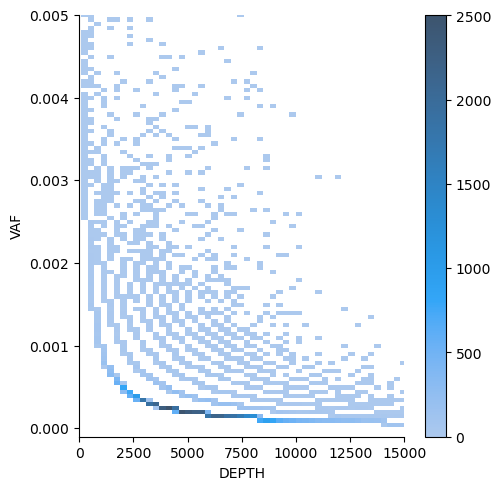

In [19]:
plt.figure(figsize = (3, 3))
sns.displot(data = df,
                x = "DEPTH",
                y = "VAF",
                #hue = "Protein_affecting",
                binwidth=(300, .00005),
                cbar=True
               )
plt.ylim(-0.0001,0.005)
plt.xlim(0,15000)
plt.show()

<Figure size 200x100 with 0 Axes>

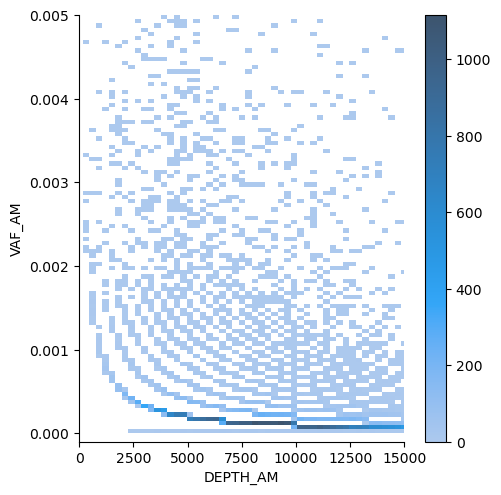

In [28]:
plt.figure(figsize = (2, 1))
sns.displot(data = df,
                x = "DEPTH_AM",
                y = "VAF_AM",
                #hue = "Protein_affecting",
                binwidth=(300, .00005),
                cbar=True
               )
plt.ylim(-0.0001,0.005)
plt.xlim(0,15000)
plt.show()

<Figure size 200x100 with 0 Axes>

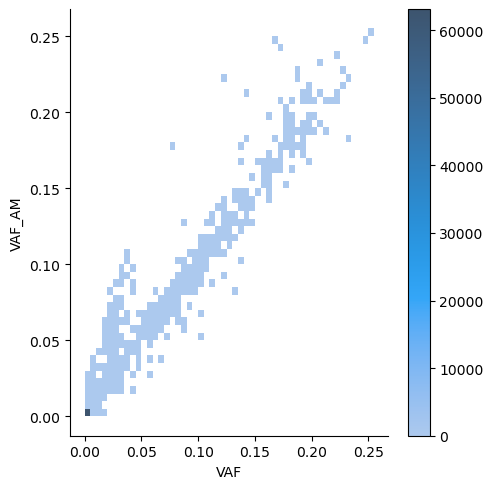

In [34]:
plt.figure(figsize = (2, 1))
sns.displot(data = df,
                x = "VAF",
                y = "VAF_AM",
                #hue = "Protein_affecting",
                binwidth=(.005, .005),
                cbar=True
               )
# plt.ylim(-0.0001,0.005)
# plt.xlim(-0.0001,0.005)
plt.show()

<Figure size 200x100 with 0 Axes>

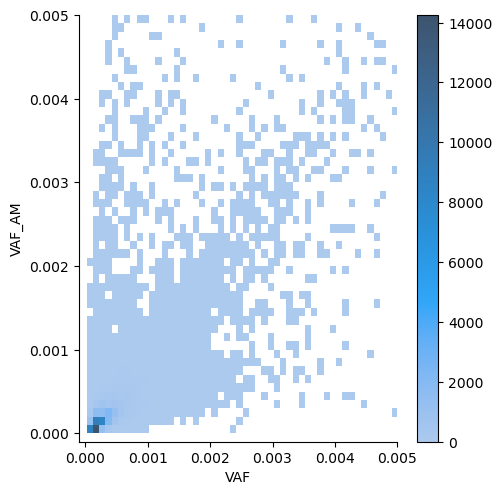

In [31]:
plt.figure(figsize = (2, 1))
sns.displot(data = df,
                x = "VAF",
                y = "VAF_AM",
                #hue = "Protein_affecting",
                binwidth=(.0001, .0001),
                cbar=True
               )
plt.ylim(-0.0001,0.005)
plt.xlim(-0.0001,0.005)
plt.show()

In [ ]:

col1 = 'VAF'
col2 = 'VAF_AM'

sns.scatterplot(
    data=df, 
    x=col1, 
    y=col2,
    ax=axes[i],
    alpha=0.6,
    marker = '.'
)


# Add a 1:1 line
global_min = min(df[col1].min(), df[col2].min())
global_max = max(df[col1].max(), df[col2].max())
axes[i].plot([global_min, global_max],
        [global_min, global_max],
        ls="--", color="red")
axes[i].set_xlabel('VAF')#, fontsize=12)
axes[i].set_ylabel('VAF AM')# ), fontsize=12)
axes[i].set_xlim(0, 0.005)
axes[i].set_ylim(0, 0.005)
# axes[i].set_xscale('log')
# axes[i].set_yscale('log')



plt.tight_layout()
plt.show()

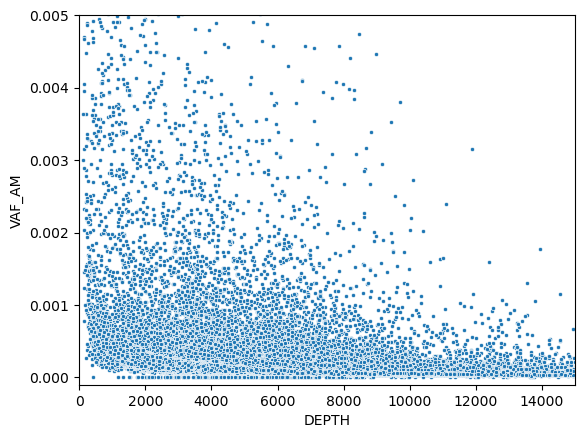

In [14]:
sns.scatterplot(data = somatic_maf_df,
                x = "DEPTH",
                y = "VAF_AM",
                #hue = "Protein_affecting",
                marker = '.'
               )
# plt.yscale('log')
# plt.xscale('log')
# plt.title(criteria)
plt.ylim(-0.0001,0.005)
plt.xlim(0,15000)

plt.show()

# 'VAF_distorsion', 'VAF_Ns', 'VAF_Ns_AM'

### Fig 3

### Fig 4

In [11]:
# filter and somatic only
maf_df_f = maf_df.loc[(maf_df["DEPTH"] >= 40) &
                      (maf_df["VAF"] < 0.3) &
                      (maf_df["VAF_AM"] < 0.3) &
                      (maf_df["vd_VAF"] < 0.3) &
                      # (maf_df["TYPE"] == "SNV") & 
                      (~maf_df["FILTER.not_covered"]) # &
                    #   (~maf_df["FILTER.NM20"])
                      # (maf_df["FILTER.repetitive_variant"] == False) & # filter not well defined yet; may hide hotspots
                      # (maf_df["FILTER.low_complex_repetitive"] == True) & # filter in principle no needed after doing AS-XS test, as in general low complex seem to be no problematic in terms of alignment
                      # (maf_df["FILTER.n_rich"] == False) &
                      # (maf_df["FILTER.low_mappability"] == False) &
                      # (maf_df["FILTER.other_sample_SNP"] == False)
                     ].reset_index(drop = True)
print(maf_df_f[maf_df_f['VAF_distortion'] > 3].shape[0], maf_df_f.shape[0])
maf_df_f.head()

777 64278


,CHROM,POS,REF,ALT,FILTER,INFO,FORMAT,SAMPLE,DEPTH,ALT_DEPTH,...,FILTER.AM_not_searched_SV,FILTER.not_searched_SV,FILTER.SN1.5,FILTER.q22.5,FILTER.v1,FILTER.low_mappability,FILTER.Bias,FILTER.d3,MUT,VAF_AM-VAF
0,chr1,26729450,T,C,low_complex_repetitive;not_in_exons;pSTD,SAMPLE=P19_0024_BTR_01;TYPE=SNV;DP=930;VD=1;AF...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:930:1:929,1:0.0011:929,0:1,0:930:929,1:3:1...",930,1,...,False,False,False,False,False,False,False,False,"T"">""C",-0.000525
1,chr1,26729474,TAG,T,low_complex_repetitive;not_in_exons;pSTD,SAMPLE=P19_0014_BDO_01;TYPE=Deletion;DP=1470;V...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:1470:1:1469,1:0.0007:1469,0:1,0:1470:1469,...",1470,1,...,False,False,False,False,False,False,False,False,-,-0.000203
2,chr1,26729479,TTC,T,low_complex_repetitive;not_in_exons;pSTD,SAMPLE=P19_0023_BDO_01;TYPE=Deletion;DP=1984;V...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:1984:1:1983,1:0.0005:1983,0:1,0:1961:1960,...",1961,1,...,False,False,False,False,False,False,False,False,-,-0.000207
3,chr1,26729563,G,C,not_in_exons;pSTD,SAMPLE=P19_0023_BDO_01;TYPE=SNV;DP=3490;VD=1;A...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:3490:1:3489,1:0.0003:2657,832:1,0:3490:348...",3490,1,...,False,False,False,False,False,False,False,False,"C"">""G",-0.000116
4,chr1,26729566,TA,T,not_in_exons;p10;pSTD,SAMPLE=P19_0040_BTR_01;TYPE=Deletion;DP=2168;V...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:2168:1:2167,1:0.0005:1845,322:0,1:2114:211...",2114,1,...,False,False,False,False,False,False,False,False,-,0.000126


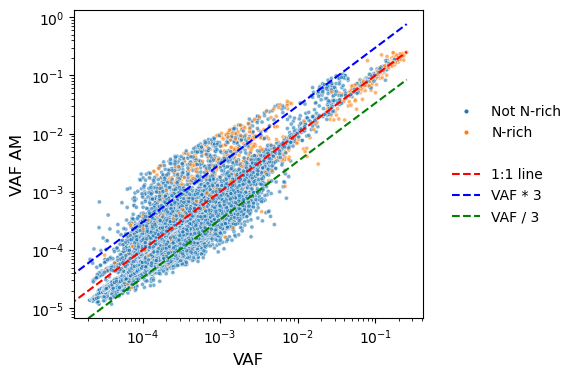

In [12]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 1, figsize=(4.5, 4))
ax = axes

df = maf_df_f
col1 = 'VAF'
col2 = 'VAF_AM'
deviation_factor = 3

# Scatter plot
scatter = sns.scatterplot(
    data=df, 
    x=col1, 
    y=col2,
    ax=ax,
    hue='FILTER.cohort_n_rich_uni',
    alpha=0.6,
    marker='.'
)

# Add a 1:1 line
global_min = min(df[col1].min(), df[col2].min()) #* 0.9
global_max = max(df[col1].max(), df[col2].max()) #* 1.3

ax.plot([global_min, global_max],
        [global_min, global_max],
        ls="--", color="red")

if deviation_factor > 0:
    ax.plot([global_min, global_max], [global_min * deviation_factor, global_max * deviation_factor], 
            ls="--", color="blue", label='3x above')
    ax.plot([global_min, global_max], [global_min / deviation_factor, global_max / deviation_factor], 
            ls="--", color="green", label='3x below')

# Set labels and scales
ax.set_xlabel('VAF', fontsize=12)
ax.set_ylabel('VAF AM', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')

# ax.set_xlim(global_min, global_max)
# ax.set_ylim(global_min, global_max)

# ax.set_aspect('equal', adjustable='box')


# Custom legend with scatter markers
legend_elements = [
    # Scatter points
    Line2D([0], [0], marker='.', color='w', markerfacecolor='#1f77b4', markersize=8, label='Not N-rich'),
    Line2D([0], [0], marker='.', color='w', markerfacecolor='#ff7f0e', markersize=8, label='N-rich'),
    Line2D([0], [0], marker='.', color='w', markerfacecolor='w', markersize=8, label=''),
    
    # Diagonal lines
    Line2D([0], [0], linestyle='--', color='red', label='1:1 line'),
    Line2D([0], [0], linestyle='--', color='blue', label='VAF * 3'),
    Line2D([0], [0], linestyle='--', color='green', label='VAF / 3')
]
ax.legend(handles=legend_elements, frameon=False, loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=10)

# plt.tight_layout()
plt.show()


### Fig 6

In [98]:
# filter and somatic only
maf_df_f = maf_df.loc[(maf_df["DEPTH"] >= 40) &
                      (maf_df["VAF"] < 0.3) &
                      (maf_df["VAF_AM"] < 0.3) &
                      (maf_df["vd_VAF"] < 0.3) &
                      (maf_df["TYPE"] == "SNV") & 
                      (~maf_df["FILTER.not_in_panel"]) &
                      (~maf_df["FILTER.NM20"])
                      # (maf_df["FILTER.repetitive_variant"] == False) & # filter not well defined yet; may hide hotspots
                      # (maf_df["FILTER.low_complex_repetitive"] == True) & # filter in principle no needed after doing AS-XS test, as in general low complex seem to be no problematic in terms of alignment
                      # (maf_df["FILTER.n_rich"] == False) &
                      # (maf_df["FILTER.low_mappability"] == False) &
                      # (maf_df["FILTER.other_sample_SNP"] == False)
                     ].reset_index(drop = True)
maf_df_f.head()

,CHROM,POS,REF,ALT,FILTER,INFO,FORMAT,SAMPLE,DEPTH,ALT_DEPTH,REF_DEPTH,VAF,vd_DEPTH,vd_ALT_DEPTH,vd_REF_DEPTH,vd_VAF,numNs,DEPTH_AM,ALT_DEPTH_AM,REF_DEPTH_AM,numNs_AM,VAF_AM,DEPTH_ND,ALT_DEPTH_ND,VAF_ND,VAF_distorted,VAF_distorted_reduced,VAF_distorted_expanded,VAF_distortion,MUT_ID,SAMPLE_ID,METHOD,PROJECT_NAME,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,SYMBOL,SYMBOL_SOURCE,HGNC_ID,CANONICAL,ENSP,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,canonical_Location,canonical_Allele,canonical_Gene,canonical_Feature,canonical_Feature_type,canonical_Consequence,canonical_cDNA_position,canonical_CDS_position,canonical_Protein_position,canonical_Amino_acids,canonical_Codons,canonical_Existing_variation,canonical_IMPACT,canonical_DISTANCE,canonical_STRAND,canonical_FLAGS,canonical_SYMBOL,canonical_SYMBOL_SOURCE,canonical_HGNC_ID,canonical_CANONICAL,canonical_ENSP,canonical_CLIN_SIG,canonical_SOMATIC,canonical_PHENO,canonical_Consequence_single,canonical_Consequence_broader,canonical_Protein_affecting,Consequence_single,Consequence_broader,Protein_affecting,CONTEXT_MUT,CONTEXT_MUT_SIGPRO,CHROM_ensembl,POS_ensembl,REF_ensembl,ALT_ensembl,TYPE,INDEL_LENGTH,INDEL_INFRAME,INDEL_MULTIPLE3,FILTER.not_in_panel,FILTER.low_complex_repetitive,FILTER.pSTD,FILTER.v2,FILTER.PASS,FILTER.repetitive_variant,FILTER.p8,FILTER.no_pileup_support,FILTER.cohort_n_rich,FILTER.cohort_n_rich_uni,FILTER.n_rich,FILTER.other_sample_SNP,FILTER.not_searched_COMPLEX,FILTER.LongMSI,FILTER.NM20,FILTER.MSI12,FILTER.Bias,FILTER.low_mappability,FILTER.SN1.5,FILTER.q22.5,FILTER.not_searched_SV,FILTER.Q10,FILTER.d3,MUT,VAF_AM-VAF
0,chr1,26729642,A,G,pSTD;v2,SAMPLE=P19_0041_BDO_01;TYPE=SNV;DP=5322;VD=1;A...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:5322:1:5321,1:0.0002:3067,2254:1,0:5322:53...",5322,1,5321,0.000188,5322,1,5321,0.000188,33,9739,1,9738,9,0.000103,4417,0,0.0,False,False,False,0.546463,chr1:26729642_A>G,P19_0041_BDO_01,med,NaN,chr1:26729642,G,ENSG00000117713,ENST00000324856,Transcript,"splice_polypyrimidine_tract_variant,intron_var...",-,-,-,-,-,-,LOW,-,1,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,chr1:26729642,G,ENSG00000117713,ENST00000324856,Transcript,"splice_polypyrimidine_tract_variant,intron_var...",-,-,-,-,-,-,LOW,-,1.0,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,splice_polypyrimidine_tract_variant,splice_region_variant,ambiguous,splice_polypyrimidine_tract_variant,splice_region_variant,ambiguous,ATA>C,A[T>C]A,1,26729642,A,G,SNV,0,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,"T"">""C",-0.000085
1,chr1,26729643,T,G,pSTD;v2,SAMPLE=P19_0033_BDO_01;TYPE=SNV;DP=6717;VD=1;A...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:6717:1:6716,1:0.0001:4733,1983:1,0:6719:67...",6719,1,6718,0.000149,6717,1,6716,0.000149,144,14550,1,14548,97,0.000069,7831,0,0.0,False,False,False,0.461787,chr1:26729643_T>G,P19_0033_BDO_01,med,NaN,chr1:26729643,G,ENSG00000117713,ENST00000324856,Transcript,"splice_region_variant,splice_polypyrimidine_tr...",-,-,-,-,-,-,LOW,-,1,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,chr1:26729643,G,ENSG00000117713,ENST00000324856,Transcript,"splice_region_variant,splice_polypyrimidine_tr...",-,-,-,-,-,-,LOW,-,1.0,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,splice_region_variant,splice_region_variant,ambiguous,splice_region_variant,splice_region_variant,ambiguous,ATT>G,A[T>G]T,1,26729643,T,G,SNV,0,False,False,False,False,True,True,False,False,

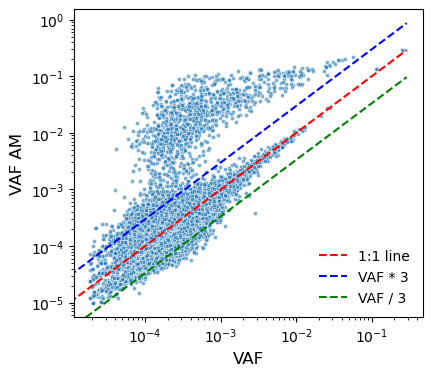

In [99]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 1, figsize=(4.5, 4))
ax = axes

df = maf_df_f
col1 = 'VAF'
col2 = 'VAF_AM'
deviation_factor = 3

# Scatter plot
scatter = sns.scatterplot(
    data=df, 
    x=col1, 
    y=col2,
    ax=ax,
    alpha=0.6,
    marker='.'
)

# Add a 1:1 line
global_min = min(df[col1].min(), df[col2].min()) #* 0.9
global_max = max(df[col1].max(), df[col2].max()) #* 1.3

ax.plot([global_min, global_max],
        [global_min, global_max],
        ls="--", color="red")

if deviation_factor > 0:
    ax.plot([global_min, global_max], [global_min * deviation_factor, global_max * deviation_factor], 
            ls="--", color="blue", label='3x above')
    ax.plot([global_min, global_max], [global_min / deviation_factor, global_max / deviation_factor], 
            ls="--", color="green", label='3x below')

# Set labels and scales
ax.set_xlabel('VAF', fontsize=12)
ax.set_ylabel('VAF AM', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')

# ax.set_xlim(global_min, global_max)
# ax.set_ylim(global_min, global_max)

# ax.set_aspect('equal', adjustable='box')


# Custom legend with scatter markers
legend_elements = [
    # Diagonal lines
    Line2D([0], [0], linestyle='--', color='red', label='1:1 line'),
    Line2D([0], [0], linestyle='--', color='blue', label='VAF * 3'),
    Line2D([0], [0], linestyle='--', color='green', label='VAF / 3')
]
ax.legend(handles=legend_elements, frameon=False, loc="lower right", fontsize=10)


plt.show()

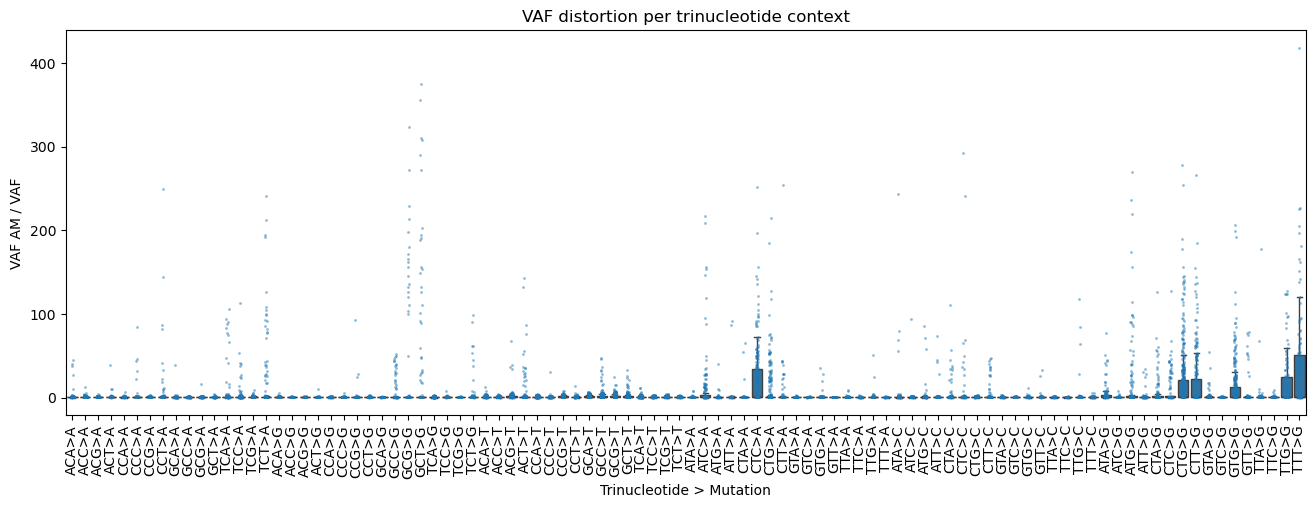

In [100]:
maf_plot = maf_df_f.sort_values( by = ["MUT", "CONTEXT_MUT"]).reset_index(drop = True) 

plt.figure(figsize = (16,5))
sns.boxplot(data = maf_plot,
            x = "CONTEXT_MUT",
            y = "VAF_distortion",
            color = '#1f77b4',
            showfliers=False,
            legend = False)

# Plot VAF of Ns
sns.stripplot(data=maf_plot,
              x ="CONTEXT_MUT",
              y = "VAF_distortion",
              facecolor = '#1f77b4',
              dodge = True,
              jitter=True,
              size=2,
              alpha = 0.5,
              legend = False)

plt.xticks(rotation = 90)
plt.title("VAF distortion per trinucleotide context")
plt.ylabel("VAF AM / VAF")
plt.xlabel("Trinucleotide > Mutation")
plt.show()

In [101]:
# filter and somatic only
maf_df_f = maf_df.loc[(maf_df["DEPTH"] >= 40) &
                      (maf_df["VAF"] < 0.3) &
                      (maf_df["VAF_AM"] < 0.3) &
                      (maf_df["vd_VAF"] < 0.3) &
                      (maf_df["TYPE"] == "SNV") & 
                      (~maf_df["FILTER.not_in_panel"]) &
                      (~maf_df["FILTER.no_pileup_support"]) &
                      (~maf_df["FILTER.NM20"]) &
                      (~maf_df["FILTER.cohort_n_rich_uni"]) &
                      (~maf_df["FILTER.low_mappability"]) &
                      (~maf_df["FILTER.other_sample_SNP"]) &
                      (~maf_df["VAF_distorted_expanded"])
                     ].reset_index(drop = True)
maf_df_f.head()

,CHROM,POS,REF,ALT,FILTER,INFO,FORMAT,SAMPLE,DEPTH,ALT_DEPTH,REF_DEPTH,VAF,vd_DEPTH,vd_ALT_DEPTH,vd_REF_DEPTH,vd_VAF,numNs,DEPTH_AM,ALT_DEPTH_AM,REF_DEPTH_AM,numNs_AM,VAF_AM,DEPTH_ND,ALT_DEPTH_ND,VAF_ND,VAF_distorted,VAF_distorted_reduced,VAF_distorted_expanded,VAF_distortion,MUT_ID,SAMPLE_ID,METHOD,PROJECT_NAME,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,SYMBOL,SYMBOL_SOURCE,HGNC_ID,CANONICAL,ENSP,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,canonical_Location,canonical_Allele,canonical_Gene,canonical_Feature,canonical_Feature_type,canonical_Consequence,canonical_cDNA_position,canonical_CDS_position,canonical_Protein_position,canonical_Amino_acids,canonical_Codons,canonical_Existing_variation,canonical_IMPACT,canonical_DISTANCE,canonical_STRAND,canonical_FLAGS,canonical_SYMBOL,canonical_SYMBOL_SOURCE,canonical_HGNC_ID,canonical_CANONICAL,canonical_ENSP,canonical_CLIN_SIG,canonical_SOMATIC,canonical_PHENO,canonical_Consequence_single,canonical_Consequence_broader,canonical_Protein_affecting,Consequence_single,Consequence_broader,Protein_affecting,CONTEXT_MUT,CONTEXT_MUT_SIGPRO,CHROM_ensembl,POS_ensembl,REF_ensembl,ALT_ensembl,TYPE,INDEL_LENGTH,INDEL_INFRAME,INDEL_MULTIPLE3,FILTER.not_in_panel,FILTER.low_complex_repetitive,FILTER.pSTD,FILTER.v2,FILTER.PASS,FILTER.repetitive_variant,FILTER.p8,FILTER.no_pileup_support,FILTER.cohort_n_rich,FILTER.cohort_n_rich_uni,FILTER.n_rich,FILTER.other_sample_SNP,FILTER.not_searched_COMPLEX,FILTER.LongMSI,FILTER.NM20,FILTER.MSI12,FILTER.Bias,FILTER.low_mappability,FILTER.SN1.5,FILTER.q22.5,FILTER.not_searched_SV,FILTER.Q10,FILTER.d3,MUT,VAF_AM-VAF
0,chr1,26729642,A,G,pSTD;v2,SAMPLE=P19_0041_BDO_01;TYPE=SNV;DP=5322;VD=1;A...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:5322:1:5321,1:0.0002:3067,2254:1,0:5322:53...",5322,1,5321,0.000188,5322,1,5321,0.000188,33,9739,1,9738,9,0.000103,4417,0,0.0,False,False,False,0.546463,chr1:26729642_A>G,P19_0041_BDO_01,med,NaN,chr1:26729642,G,ENSG00000117713,ENST00000324856,Transcript,"splice_polypyrimidine_tract_variant,intron_var...",-,-,-,-,-,-,LOW,-,1,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,chr1:26729642,G,ENSG00000117713,ENST00000324856,Transcript,"splice_polypyrimidine_tract_variant,intron_var...",-,-,-,-,-,-,LOW,-,1.0,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,splice_polypyrimidine_tract_variant,splice_region_variant,ambiguous,splice_polypyrimidine_tract_variant,splice_region_variant,ambiguous,ATA>C,A[T>C]A,1,26729642,A,G,SNV,0,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,"T"">""C",-0.000085
1,chr1,26729643,T,G,pSTD;v2,SAMPLE=P19_0033_BDO_01;TYPE=SNV;DP=6717;VD=1;A...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:6717:1:6716,1:0.0001:4733,1983:1,0:6719:67...",6719,1,6718,0.000149,6717,1,6716,0.000149,144,14550,1,14548,97,0.000069,7831,0,0.0,False,False,False,0.461787,chr1:26729643_T>G,P19_0033_BDO_01,med,NaN,chr1:26729643,G,ENSG00000117713,ENST00000324856,Transcript,"splice_region_variant,splice_polypyrimidine_tr...",-,-,-,-,-,-,LOW,-,1,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,chr1:26729643,G,ENSG00000117713,ENST00000324856,Transcript,"splice_region_variant,splice_polypyrimidine_tr...",-,-,-,-,-,-,LOW,-,1.0,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,splice_region_variant,splice_region_variant,ambiguous,splice_region_variant,splice_region_variant,ambiguous,ATT>G,A[T>G]T,1,26729643,T,G,SNV,0,False,False,False,False,True,True,False,False,

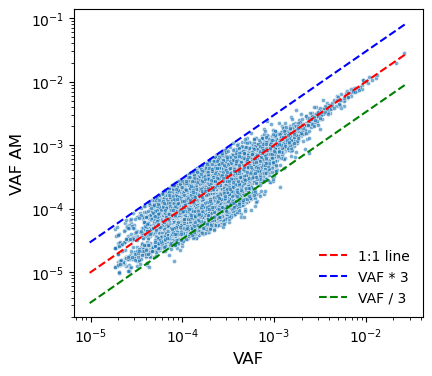

In [102]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 1, figsize=(4.5, 4))
ax = axes

df = maf_df_f
col1 = 'VAF'
col2 = 'VAF_AM'
deviation_factor = 3

# Scatter plot
scatter = sns.scatterplot(
    data=df, 
    x=col1, 
    y=col2,
    ax=ax,
    alpha=0.6,
    marker='.'
)

# Add a 1:1 line
global_min = min(df[col1].min(), df[col2].min()) #* 0.9
global_max = max(df[col1].max(), df[col2].max()) #* 1.3

ax.plot([global_min, global_max],
        [global_min, global_max],
        ls="--", color="red")

if deviation_factor > 0:
    ax.plot([global_min, global_max], [global_min * deviation_factor, global_max * deviation_factor], 
            ls="--", color="blue", label='3x above')
    ax.plot([global_min, global_max], [global_min / deviation_factor, global_max / deviation_factor], 
            ls="--", color="green", label='3x below')

# Set labels and scales
ax.set_xlabel('VAF', fontsize=12)
ax.set_ylabel('VAF AM', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')

# ax.set_xlim(global_min, global_max)
# ax.set_ylim(global_min, global_max)

# ax.set_aspect('equal', adjustable='box')


# Custom legend with scatter markers
legend_elements = [
    # Diagonal lines
    Line2D([0], [0], linestyle='--', color='red', label='1:1 line'),
    Line2D([0], [0], linestyle='--', color='blue', label='VAF * 3'),
    Line2D([0], [0], linestyle='--', color='green', label='VAF / 3')
]
ax.legend(handles=legend_elements, frameon=False, loc="lower right", fontsize=10)


plt.show()

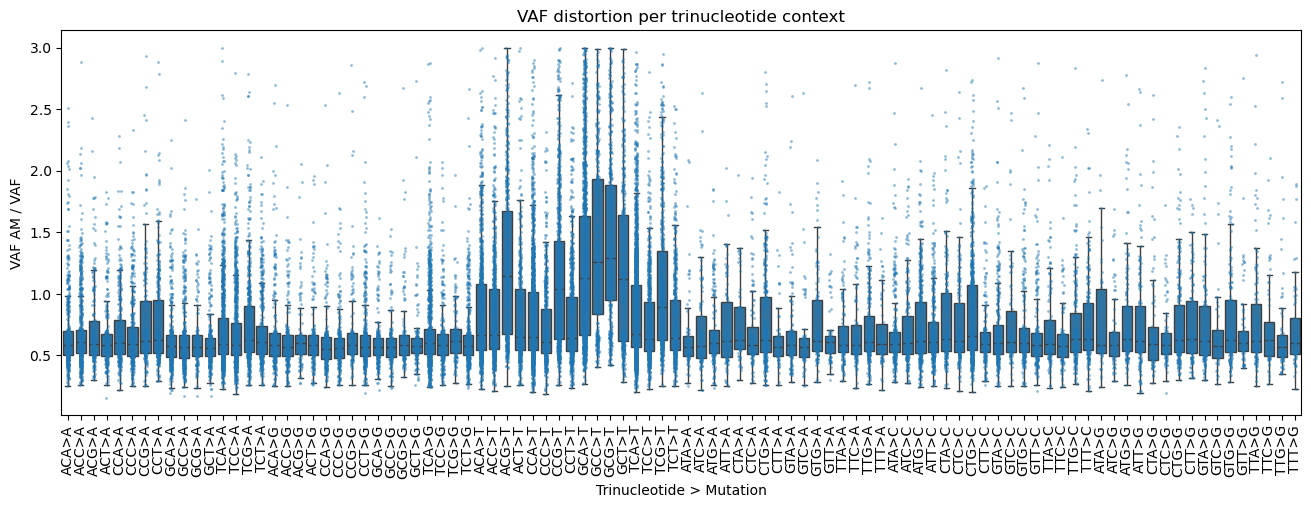

In [97]:
maf_plot = maf_df_f.sort_values( by = ["MUT", "CONTEXT_MUT"]).reset_index(drop = True) 

plt.figure(figsize = (16,5))
sns.boxplot(data = maf_plot,
            x = "CONTEXT_MUT",
            y = "VAF_distortion",
            color = '#1f77b4',
            showfliers=False,
            legend = False)

# Plot VAF of Ns
sns.stripplot(data=maf_plot,
              x ="CONTEXT_MUT",
              y = "VAF_distortion",
              facecolor = '#1f77b4',
              dodge = True,
              jitter=True,
              size=2,
              alpha = 0.5,
              legend = False)

plt.xticks(rotation = 90)
plt.title("VAF distortion per trinucleotide context")
plt.ylabel("VAF AM / VAF")
plt.xlabel("Trinucleotide > Mutation")
plt.show()

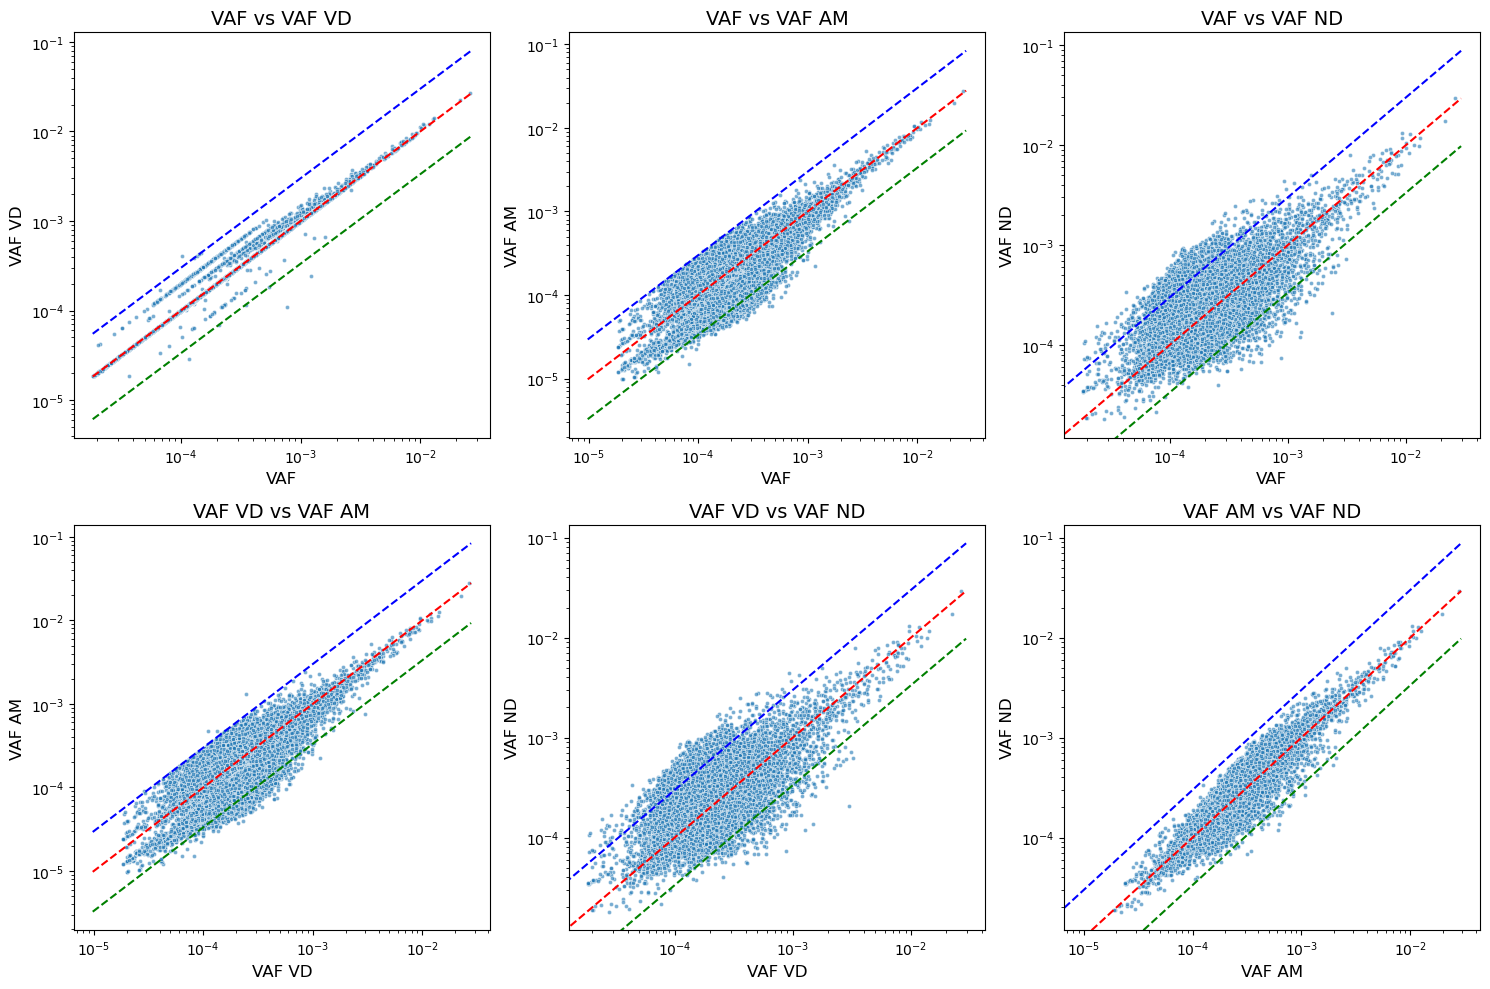

In [104]:
# Example usage:
maf_df_f["VAF VD"] = maf_df_f["vd_VAF"]
maf_df_f["VAF AM"] = maf_df_f["VAF_AM"]
maf_df_f["VAF ND"] = maf_df_f["VAF_ND"]
columns_of_interest = ['VAF', 'VAF VD', 'VAF AM', 'VAF ND']
plot_pairwise_scatterplots(maf_df_f, columns_of_interest, equal = True, deviation_factor = 3)

### Fig 7

In [114]:
somatic_maf_df = pd.read_table(somatic_maf_file)
somatic_maf_df_f = somatic_maf_df[(somatic_maf_df["DEPTH"] >= 40) &
                                 (~somatic_maf_df["FILTER.not_in_panel"])
                                 ]
somatic_maf_df_f.head()

/tmp/jobs/fcalvet/10391469/ipykernel_40449/3914976927.py:1: DtypeWarning: Columns (47,91,109) have mixed types. Specify dtype option on import or set low_memory=False.
  somatic_maf_df = pd.read_table(somatic_maf_file)


,CHROM,POS,REF,ALT,FILTER,INFO,FORMAT,SAMPLE,DEPTH,ALT_DEPTH,REF_DEPTH,VAF,vd_DEPTH,vd_ALT_DEPTH,vd_REF_DEPTH,vd_VAF,numNs,DEPTH_AM,ALT_DEPTH_AM,REF_DEPTH_AM,numNs_AM,VAF_AM,DEPTH_ND,ALT_DEPTH_ND,VAF_ND,VAF_distorted,VAF_distorted_reduced,VAF_distorted_expanded,VAF_distortion,MUT_ID,SAMPLE_ID,METHOD,PROJECT_NAME,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,SYMBOL,SYMBOL_SOURCE,HGNC_ID,CANONICAL,ENSP,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,canonical_Location,canonical_Allele,canonical_Gene,canonical_Feature,canonical_Feature_type,canonical_Consequence,canonical_cDNA_position,canonical_CDS_position,canonical_Protein_position,canonical_Amino_acids,canonical_Codons,canonical_Existing_variation,canonical_IMPACT,canonical_DISTANCE,canonical_STRAND,canonical_FLAGS,canonical_SYMBOL,canonical_SYMBOL_SOURCE,canonical_HGNC_ID,canonical_CANONICAL,canonical_ENSP,canonical_CLIN_SIG,canonical_SOMATIC,canonical_PHENO,canonical_Consequence_single,canonical_Consequence_broader,canonical_Protein_affecting,Consequence_single,Consequence_broader,Protein_affecting,CONTEXT_MUT,CONTEXT_MUT_SIGPRO,CHROM_ensembl,POS_ensembl,REF_ensembl,ALT_ensembl,TYPE,INDEL_LENGTH,INDEL_INFRAME,INDEL_MULTIPLE3,FILTER.not_in_panel,FILTER.low_complex_repetitive,FILTER.pSTD,FILTER.v2,FILTER.PASS,FILTER.repetitive_variant,FILTER.p8,FILTER.no_pileup_support,FILTER.cohort_n_rich,FILTER.cohort_n_rich_uni,FILTER.n_rich,FILTER.other_sample_SNP,FILTER.not_searched_COMPLEX,FILTER.LongMSI,FILTER.NM20,FILTER.MSI12,FILTER.Bias,FILTER.low_mappability,FILTER.SN1.5,FILTER.q22.5,FILTER.not_searched_SV,FILTER.Q10,FILTER.d3
11,chr1,26729642,A,G,pSTD;v2,SAMPLE=P19_0041_BDO_01;TYPE=SNV;DP=5322;VD=1;A...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:5322:1:5321,1:0.0002:3067,2254:1,0:5322:53...",5322,1,5321,0.000188,5322,1,5321,0.000188,33,9739,1,9738,9,0.000103,4417,0,0.0,False,False,False,0.546463,chr1:26729642_A>G,P19_0041_BDO_01,med,NaN,chr1:26729642,G,ENSG00000117713,ENST00000324856,Transcript,"splice_polypyrimidine_tract_variant,intron_var...",-,-,-,-,-,-,LOW,-,1,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,chr1:26729642,G,ENSG00000117713,ENST00000324856,Transcript,"splice_polypyrimidine_tract_variant,intron_var...",-,-,-,-,-,-,LOW,-,1.0,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,splice_polypyrimidine_tract_variant,splice_region_variant,ambiguous,splice_polypyrimidine_tract_variant,splice_region_variant,ambiguous,ATA>C,A[T>C]A,1,26729642,A,G,SNV,0,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12,chr1,26729643,T,G,pSTD;v2,SAMPLE=P19_0033_BDO_01;TYPE=SNV;DP=6717;VD=1;A...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:6717:1:6716,1:0.0001:4733,1983:1,0:6719:67...",6719,1,6718,0.000149,6717,1,6716,0.000149,144,14550,1,14548,97,0.000069,7831,0,0.0,False,False,False,0.461787,chr1:26729643_T>G,P19_0033_BDO_01,med,NaN,chr1:26729643,G,ENSG00000117713,ENST00000324856,Transcript,"splice_region_variant,splice_polypyrimidine_tr...",-,-,-,-,-,-,LOW,-,1,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,chr1:26729643,G,ENSG00000117713,ENST00000324856,Transcript,"splice_region_variant,splice_polypyrimidine_tr...",-,-,-,-,-,-,LOW,-,1.0,-,ARID1A,HGNC,HGNC:11110,YES,ENSP00000320485,-,-,-,splice_region_variant,splice_region_variant,ambiguous,splice_region_variant,splice_region_variant,ambiguous,ATT>G,A[T>G]T,1,26729643,T,G,SNV,0,False,False,False,False,True,True,False,False,False,False,False,False,False,Fal

In [117]:
somatic_maf_df_f[somatic_maf_df_f['VAF'] > 0.1]

,CHROM,POS,REF,ALT,FILTER,INFO,FORMAT,SAMPLE,DEPTH,ALT_DEPTH,REF_DEPTH,VAF,vd_DEPTH,vd_ALT_DEPTH,vd_REF_DEPTH,vd_VAF,numNs,DEPTH_AM,ALT_DEPTH_AM,REF_DEPTH_AM,numNs_AM,VAF_AM,DEPTH_ND,ALT_DEPTH_ND,VAF_ND,VAF_distorted,VAF_distorted_reduced,VAF_distorted_expanded,VAF_distortion,MUT_ID,SAMPLE_ID,METHOD,PROJECT_NAME,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,SYMBOL,SYMBOL_SOURCE,HGNC_ID,CANONICAL,ENSP,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,canonical_Location,canonical_Allele,canonical_Gene,canonical_Feature,canonical_Feature_type,canonical_Consequence,canonical_cDNA_position,canonical_CDS_position,canonical_Protein_position,canonical_Amino_acids,canonical_Codons,canonical_Existing_variation,canonical_IMPACT,canonical_DISTANCE,canonical_STRAND,canonical_FLAGS,canonical_SYMBOL,canonical_SYMBOL_SOURCE,canonical_HGNC_ID,canonical_CANONICAL,canonical_ENSP,canonical_CLIN_SIG,canonical_SOMATIC,canonical_PHENO,canonical_Consequence_single,canonical_Consequence_broader,canonical_Protein_affecting,Consequence_single,Consequence_broader,Protein_affecting,CONTEXT_MUT,CONTEXT_MUT_SIGPRO,CHROM_ensembl,POS_ensembl,REF_ensembl,ALT_ensembl,TYPE,INDEL_LENGTH,INDEL_INFRAME,INDEL_MULTIPLE3,FILTER.not_in_panel,FILTER.low_complex_repetitive,FILTER.pSTD,FILTER.v2,FILTER.PASS,FILTER.repetitive_variant,FILTER.p8,FILTER.no_pileup_support,FILTER.cohort_n_rich,FILTER.cohort_n_rich_uni,FILTER.n_rich,FILTER.other_sample_SNP,FILTER.not_searched_COMPLEX,FILTER.LongMSI,FILTER.NM20,FILTER.MSI12,FILTER.Bias,FILTER.low_mappability,FILTER.SN1.5,FILTER.q22.5,FILTER.not_searched_SV,FILTER.Q10,FILTER.d3
17223,chr12,49032483,TTG,T,repetitive_variant,SAMPLE=P19_0010_BTR_01;TYPE=Deletion;DP=6208;V...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:6208:1602:4606,1602:0.2581:2228,2378:779,8...",6090,1384,4700,0.227258,6208,1602,4606,0.258054,49,15621,3514,12107,20,0.224954,9531,2130,0.223481,False,False,False,0.989861,chr12:49032483_TTG>T,P19_0010_BTR_01,med,NaN,chr12:49032484-49032485,-,ENSG00000167548,ENST00000301067,Transcript,frameshift_variant,13439-13440,12220-12221,4074,Q/X,CAa/a,-,HIGH,-,-1,-,KMT2D,HGNC,HGNC:7133,YES,ENSP00000301067,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,chr12:49032484-49032485,-,ENSG00000167548,ENST00000301067,Transcript,frameshift_variant,13439-13440,12220-12221,4074,Q/X,CAa/a,-,HIGH,-,-1.0,-,KMT2D,HGNC,HGNC:7133,YES,ENSP00000301067,-,-,-,frameshift_variant,nonsense,protein_affecting,frameshift_variant,nonsense,protein_affecting,-,-,12,49032484,TG,-,DELETION,2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17225,chr12,49032483,TTG,T,repetitive_variant,SAMPLE=P19_0010_BDO_01;TYPE=Deletion;DP=6418;V...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:6418:1761:4657,1761:0.2744:2226,2431:860,9...",6310,1528,4769,0.242155,6418,1761,4657,0.274385,45,14925,3511,11414,19,0.235243,8615,1983,0.230180,False,False,False,0.971455,chr12:49032483_TTG>T,P19_0010_BDO_01,med,NaN,chr12:49032484-49032485,-,ENSG00000167548,ENST00000301067,Transcript,frameshift_variant,13439-13440,12220-12221,4074,Q/X,CAa/a,-,HIGH,-,-1,-,KMT2D,HGNC,HGNC:7133,YES,ENSP00000301067,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,chr12:49032484-49032485,-,ENSG00000167548,ENST00000301067,Transcript,frameshift_variant,13439-13440,12220-12221,4074,Q/X,CAa/a,-,HIGH,-,-1.0,-,KMT2D,HGNC,HGNC:7133,YES,ENSP00000301067,-,-,-,frameshift_variant,nonsense,protein_affecting,frameshift_variant,nonsense,protein_affecting,-,-,12,49032484,TG,-,DELETION,2,False,False,False,False,False,False,False,Tr

In [115]:
# # filter and somatic only
# maf_df_f = maf_df.loc[(maf_df["DEPTH"] >= 40) &
#                       (maf_df["VAF"] < 0.3) &
#                       (maf_df["VAF_AM"] < 0.3) &
#                       (maf_df["vd_VAF"] < 0.3) &
#                       (maf_df["TYPE"] == "SNV") & 
#                       (~maf_df["FILTER.not_in_panel"]) &
#                       (~maf_df["FILTER.no_pileup_support"]) &
#                       (~maf_df["FILTER.NM20"]) &
#                       (~maf_df["FILTER.cohort_n_rich_uni"]) &
#                       (~maf_df["FILTER.low_mappability"]) &
#                       (~maf_df["FILTER.other_sample_SNP"]) &
#                       (~maf_df["VAF_distorted_expanded"])
#                      ].reset_index(drop = True)

In [ ]:
plt.h

/tmp/jobs/fcalvet/10391469/ipykernel_40449/1048330316.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([10**x for x in ax.get_xticks()])


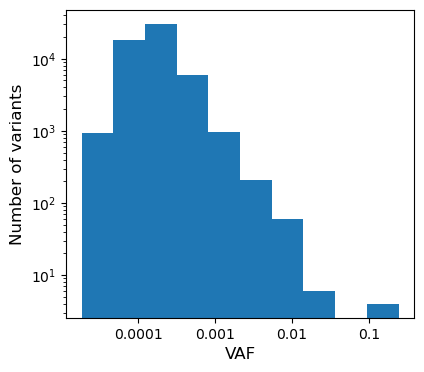

In [116]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 1, figsize=(4.5, 4))
ax = axes
ax.hist(np.log10(somatic_maf_df_f['VAF']))
# df = maf_df_f
# col1 = 'VAF'
# col2 = 'VAF_AM'
# deviation_factor = 3

# # Scatter plot
# scatter = sns.scatterplot(
#     data=df, 
#     x=col1, 
#     y=col2,
#     ax=ax,
#     alpha=0.6,
#     marker='.'
# )

# # Add a 1:1 line
# global_min = min(df[col1].min(), df[col2].min()) #* 0.9
# global_max = max(df[col1].max(), df[col2].max()) #* 1.3

# ax.plot([global_min, global_max],
#         [global_min, global_max],
#         ls="--", color="red")

# if deviation_factor > 0:
#     ax.plot([global_min, global_max], [global_min * deviation_factor, global_max * deviation_factor], 
#             ls="--", color="blue", label='3x above')
#     ax.plot([global_min, global_max], [global_min / deviation_factor, global_max / deviation_factor], 
#             ls="--", color="green", label='3x below')

# # Set labels and scales
ax.set_xlabel('VAF', fontsize=12)
ax.set_ylabel('Number of variants', fontsize=12)
# ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticklabels([10**x for x in ax.get_xticks()])

# # ax.set_xlim(global_min, global_max)
# # ax.set_ylim(global_min, global_max)

# # ax.set_aspect('equal', adjustable='box')


# # Custom legend with scatter markers
# legend_elements = [
#     # Diagonal lines
#     Line2D([0], [0], linestyle='--', color='red', label='1:1 line'),
#     Line2D([0], [0], linestyle='--', color='blue', label='VAF * 3'),
#     Line2D([0], [0], linestyle='--', color='green', label='VAF / 3')
# ]
# ax.legend(handles=legend_elements, frameon=False, loc="lower right", fontsize=10)


plt.show()